In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
%run environment.ipynb
%run agent.ipynb

In [ ]:
env = create_env()

In [ ]:
agent = QLearningAgent(
    env.observation_space.n,
    env.action_space.n
)

In [ ]:
episodes = 10000        # Total number of training episodes
epsilon = 1.0           # Initial exploration rate
epsilon_decay = 0.995   # Decay rate for epsilon per episode
epsilon_min = 0.01      # Minimum exploration rate

In [ ]:
rewards = []
steps = []

In [ ]:
print("Starting training...")

Starting training...


In [ ]:
window_size = 500

In [ ]:
for episode in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    episode_steps = 0

    while not done:
        action = agent.choose_action(state, epsilon, env.action_space)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.update(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        episode_steps += 1

    rewards.append(total_reward)
    steps.append(episode_steps)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % window_size == 0:
        avg_reward = np.mean(rewards[-window_size:])
        avg_steps = np.mean(steps[-window_size:])
        print(f"Episode {episode + 1}/{episodes} - Avg Reward: {avg_reward:.2f}, Avg Steps: {avg_steps:.2f}, Epsilon: {epsilon:.4f}")

Episode 500/10000 - Avg Reward: -319.16, Avg Steps: 146.18, Epsilon: 0.0816
Episode 1000/10000 - Avg Reward: -29.21, Avg Steps: 45.62, Epsilon: 0.0100
Episode 1500/10000 - Avg Reward: 0.93, Avg Steps: 19.44, Epsilon: 0.0100
Episode 2000/10000 - Avg Reward: 5.84, Avg Steps: 14.79, Epsilon: 0.0100
Episode 2500/10000 - Avg Reward: 6.90, Avg Steps: 13.67, Epsilon: 0.0100
Episode 3000/10000 - Avg Reward: 7.18, Avg Steps: 13.53, Epsilon: 0.0100
Episode 3500/10000 - Avg Reward: 7.35, Avg Steps: 13.20, Epsilon: 0.0100
Episode 4000/10000 - Avg Reward: 7.42, Avg Steps: 13.31, Epsilon: 0.0100
Episode 4500/10000 - Avg Reward: 7.57, Avg Steps: 13.16, Epsilon: 0.0100
Episode 5000/10000 - Avg Reward: 7.52, Avg Steps: 13.12, Epsilon: 0.0100
Episode 5500/10000 - Avg Reward: 7.45, Avg Steps: 13.17, Epsilon: 0.0100
Episode 6000/10000 - Avg Reward: 7.19, Avg Steps: 13.31, Epsilon: 0.0100
Episode 6500/10000 - Avg Reward: 7.16, Avg Steps: 13.43, Epsilon: 0.0100
Episode 7000/10000 - Avg Reward: 7.41, Avg Ste

In [ ]:
print("Training finished.")
np.save("../model/q_table.npy", agent.q_table)

Training finished.


In [ ]:
print("Generating learning curves...")

Generating learning curves...


In [ ]:
def moving_average(a, n=window_size):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [ ]:
smoothed_rewards = moving_average(rewards)
smoothed_steps = moving_average(steps)

In [ ]:
os.makedirs("../data", exist_ok=True)

Learning curves saved to data/learning_curves.png.


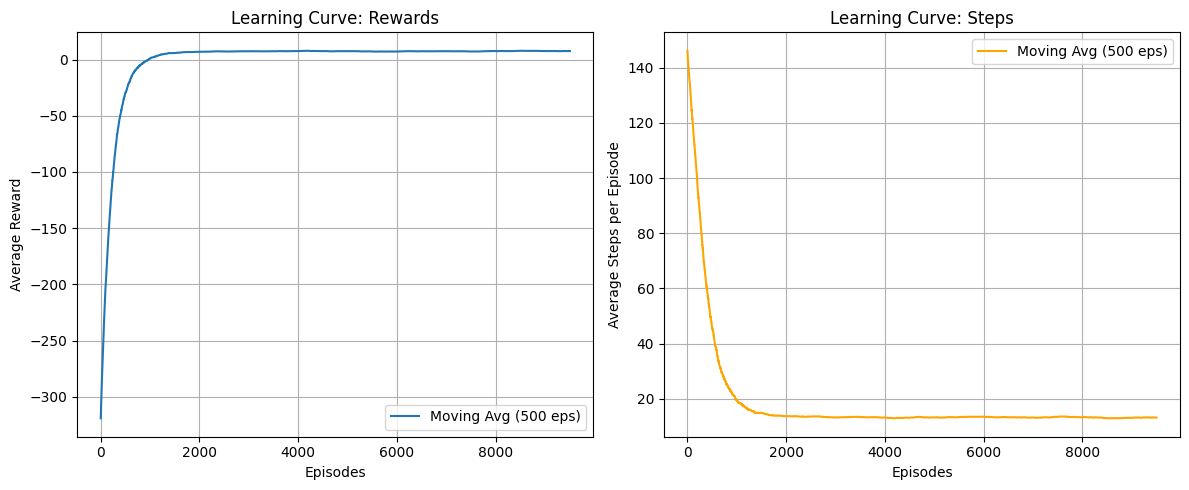

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(smoothed_rewards, label=f"Moving Avg ({window_size} eps)")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Learning Curve: Rewards")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(smoothed_steps, label=f"Moving Avg ({window_size} eps)", color="orange")
plt.xlabel("Episodes")
plt.ylabel("Average Steps per Episode")
plt.title("Learning Curve: Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../data/learning_curves.png")
print("Learning curves saved to data/learning_curves.png.")